In [2]:
import os
import re
import pickle
import copy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pymoo.indicators.igd import IGD
#from optimization.lhs import LHS

os.environ["CUDA_VISIBLE_DEVICES"]= "-1"

# Training dataset

In [3]:
def path_to_num(string):
    res = re.findall("structure_\d+_", string)[0]
    res = re.findall("\d+", res)[0]
    return int(res)


root = r"D:\inception_dataset\train"
header_names = ["structure_num", "young_module", "fem_volume_fraction"]

normal0_ym = pd.read_csv(os.path.join(root, "64_normal_0_young_modules.csv"), names=header_names)
normal15_ym = pd.read_csv(os.path.join(root, "64_normal_1.5_young_modules.csv"), names=header_names)
spheresRVE_ym = pd.read_csv(os.path.join(root, "64_spheresRVE_young_modules.csv"), names=header_names)
uniform05_ym = pd.read_csv(os.path.join(root, "64_uniform_0.5_young_modules.csv"), names=header_names)
uniform1_ym = pd.read_csv(os.path.join(root, "64_uniform_1_young_modules.csv"), names=header_names)

normal0_info = pd.read_csv(os.path.join(root, "info_64_normal_0.csv"))
normal15_info = pd.read_csv(os.path.join(root, "info_64_normal_1.5.csv"))
spheresRVE_info = pd.read_csv(os.path.join(root, "info_64_spheresRVE.csv"))
uniform05_info = pd.read_csv(os.path.join(root, "info_64_uniform_0.5.csv"))
uniform1_info = pd.read_csv(os.path.join(root, "info_64_uniform_1.csv"))

In [4]:
normal0_info["num"] = normal0_info.index.values
normal15_info["num"] = normal15_info.index.values
uniform05_info["num"] = uniform05_info.index.values
uniform1_info["num"] = uniform1_info.index.values

normal0_ym["structure_num"] = normal0_ym["structure_num"].apply(lambda x: path_to_num(x))
normal15_ym["structure_num"] = normal15_ym["structure_num"].apply(lambda x: path_to_num(x))
spheresRVE_ym["structure_num"] = spheresRVE_ym["structure_num"].apply(lambda x: path_to_num(x))
uniform05_ym["structure_num"] = uniform05_ym["structure_num"].apply(lambda x: path_to_num(x))
uniform1_ym["structure_num"] = uniform1_ym["structure_num"].apply(lambda x: path_to_num(x))

normal0_ym["class"] = "Open-cell, $N(0,1)$"
normal15_ym["class"] = "Open-cell, $N(1.5,1)$"
spheresRVE_ym["class"] = "Closed-cell"
uniform05_ym["class"] = "Open-cell, $U(-0.5,0.5)$"
uniform1_ym["class"] = "Open-cell, $U(-1,1)$"

normal0_info = normal0_info.merge(normal0_ym, how="left", left_on="num", right_on="structure_num")
normal15_info = normal15_info.merge(normal15_ym, how="left", left_on="num", right_on="structure_num")
spheresRVE_info = spheresRVE_info.merge(spheresRVE_ym, how="left", left_on="idx", right_on="structure_num")
uniform05_info = uniform05_info.merge(uniform05_ym, how="left", left_on="num", right_on="structure_num")
uniform1_info = uniform1_info.merge(uniform1_ym, how="left", left_on="num", right_on="structure_num")

train_ds_info = pd.concat([normal0_info, normal15_info, spheresRVE_info, uniform05_info, uniform1_info])

In [5]:
train_ds_info.dropna(subset="young_module", inplace=True)
train_ds_info.reset_index(drop=True, inplace=True)
train_ds_info["volume_fraction_error"] = np.abs(1 - train_ds_info["volume_fraction"] / train_ds_info["fem_volume_fraction"]) * 100

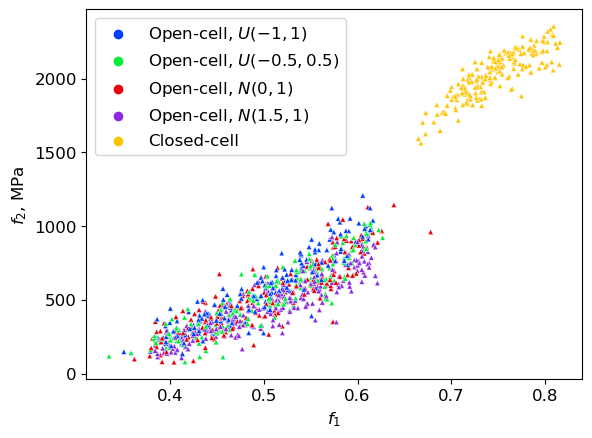

In [9]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info.sample(1000, random_state=1),
    x="volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

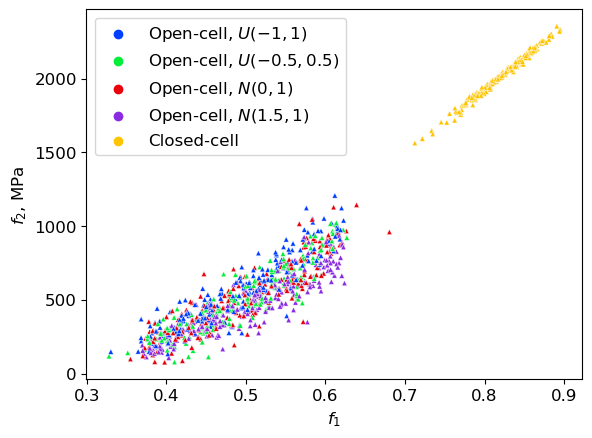

In [10]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info.sample(1000, random_state=1),
    x="fem_volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

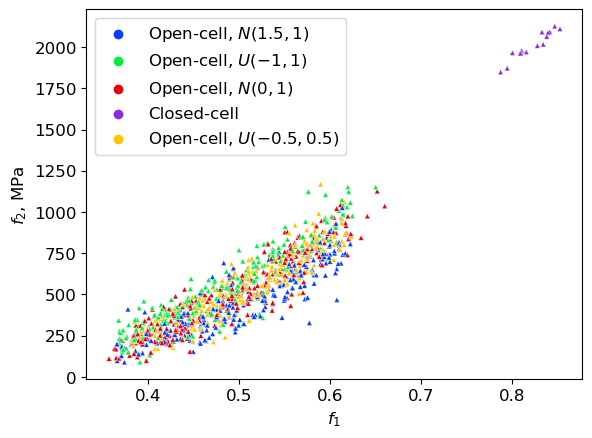

In [11]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info[train_ds_info["volume_fraction_error"] < 5].sample(1000, random_state=2),
    x="fem_volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

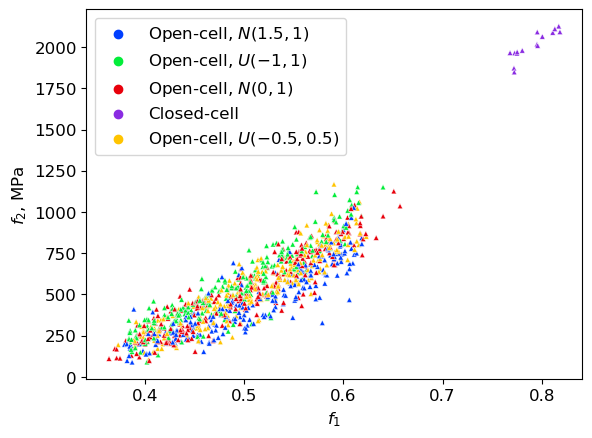

In [12]:
fig, ax = plt.subplots(dpi=dpi)
sns.scatterplot(
    ax=ax,
    data=train_ds_info[train_ds_info["volume_fraction_error"] < 5].sample(1000, random_state=2),
    x="volume_fraction",
    y="young_module",
    hue="class",
    s=15.0,
    marker="^",
    legend="full"
)
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend(title="")

# Optimization result

In [1]:
import os
import re
import pickle
import copy
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from pymoo.indicators.igd import IGD
from optimization.lhs import LHS

os.environ["CUDA_VISIBLE_DEVICES"]= "-1"

In [8]:
dpi = 100
font_size = 12
plt_style = "seaborn-bright"
plt.style.use(plt_style)
plt.rcParams.update({"font.size": font_size})

In [13]:
alpha = 0.5
fid_135 = pd.read_csv("fid_135.csv")
fid_135["EMA"] = fid_135["FID"].ewm(alpha=alpha, adjust=False).mean()

fid_no_noise_135 = pd.read_csv("fid_no_noise_135.csv")
fid_no_noise_135["EMA"] = fid_no_noise_135["FID"].ewm(alpha=alpha, adjust=False).mean()

fid_141 = pd.read_csv("fid_141.csv")
fid_141["EMA"] = fid_141["FID"].ewm(alpha=alpha, adjust=False).mean()

fid_no_noise_141 = pd.read_csv("fid_no_noise_141.csv")
fid_no_noise_141["EMA"] = fid_no_noise_141["FID"].ewm(alpha=alpha, adjust=False).mean()

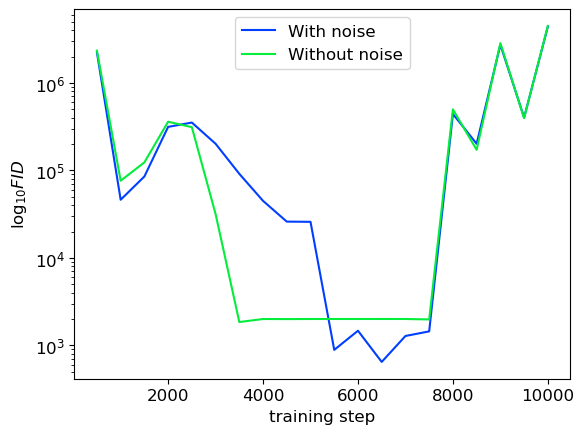

In [14]:
fig, ax = plt.subplots(dpi=dpi)

ax.plot(
    fid_135["Step"],
    fid_135["FID"],
    label="With noise"
)

ax.plot(
    fid_no_noise_135["Step"],
    fid_no_noise_135["FID"],
    label="Without noise"
)

ax.set_xlabel("training step")
ax.set_ylabel("$\log_{10}{FID}$") # MPa because the model size in millimeters
ax.set_yscale("log", base=10)
ax.legend()

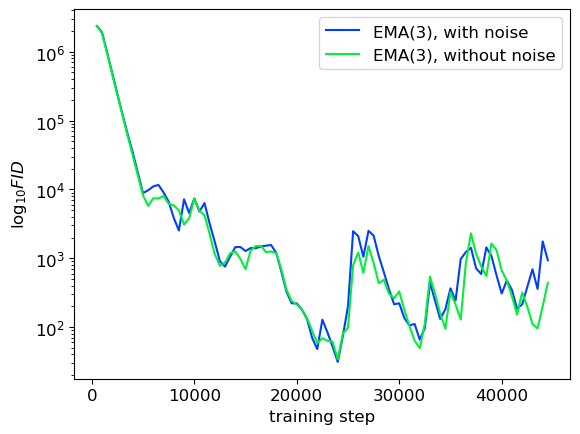

In [15]:
fig, ax = plt.subplots(dpi=dpi)

ax.plot(
    fid_141["Step"],
    fid_141["EMA"],
    label="EMA(3), with noise"
)

ax.plot(
    fid_no_noise_141["Step"],
    fid_no_noise_141["EMA"],
    label="EMA(3), without noise"
)

ax.set_xlabel("training step")
ax.set_ylabel("$\log_{10}{FID}$") # MPa because the model size in millimeters
ax.set_yscale("log", base=10)
ax.legend()

In [16]:
res_name = "024000_141_w_64_history"
with open(r"../optimization/results/" + res_name, "rb") as f:
    B_res = pickle.load(f)

B_ds = pd.DataFrame({"volume_fraction": B_res[1][:, 0], "young_module": -B_res[1][:, 1]})
B_ds["class"] = res_name

res_name = "024000_141_w_64"
with open(r"../optimization/history/" + res_name, "rb") as f:
    optimization_hist = pickle.load(f)


res_name = "024000_141_z_64_history"
with open(r"../optimization/results/" + res_name, "rb") as f:
    C_res = pickle.load(f)

C_ds = pd.DataFrame({"volume_fraction": C_res[1][:, 0], "young_module": -C_res[1][:, 1]})
C_ds["class"] = res_name

res_name = "024000_141_z_64"
with open(r"../optimization/history/" + res_name, "rb") as f:
    C_hist = pickle.load(f)
    

res_name = "024000_141_w_0.75_64_history"
with open(r"../optimization/results/" + res_name, "rb") as f:
    D_res = pickle.load(f)

D_ds = pd.DataFrame({"volume_fraction": D_res[1][:, 0], "young_module": -D_res[1][:, 1]})
D_ds["class"] = res_name

res_name = "024000_141_w_0.75_64"
with open(r"../optimization/history/" + res_name, "rb") as f:
    D_hist = pickle.load(f)


res_name = "024000_141_w_100ngen_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    A_res = pickle.load(f)

A_ds = pd.DataFrame({"volume_fraction": A_res[1][:, 0], "young_module": -A_res[1][:, 1]})
A_ds["class"] = res_name


res_name = "034000_141_w_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    F_res = pickle.load(f)

F_ds = pd.DataFrame({"volume_fraction": F_res[1][:, 0], "young_module": -F_res[1][:, 1]})
F_ds["class"] = res_name


res_name = "043000_141_w_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    G_res = pickle.load(f)

G_ds = pd.DataFrame({"volume_fraction": G_res[1][:, 0], "young_module": -G_res[1][:, 1]})
G_ds["class"] = res_name

### Сравнение обучающего набора и BEST CONFIG

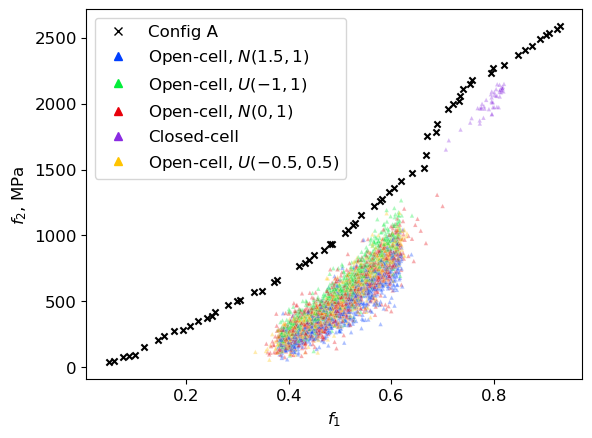

In [17]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=A_ds["volume_fraction"],
    y=A_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="Config A"
)

sns.scatterplot(
    ax=ax,
    data=train_ds_info[train_ds_info["volume_fraction_error"] < 5].sample(4000, random_state=2),
    x="volume_fraction",
    y="young_module",
    hue="class",
    s=10,
    marker="^",
    alpha=0.33
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters

letter_set1 = {"Config A"}
letter_set2 = pd.unique(train_ds_info["class"])

marker_set1 = "x"
marker_set2 = "^"

marker_for_letter = {
    **{letter: marker_set1 for letter in letter_set1},
    **{letter: marker_set2 for letter in letter_set2}
}

handles, labels = ax.get_legend_handles_labels()
handles = [
    Line2D([], [], color=h.get_facecolor(), linestyle='', marker=marker_for_letter[l])
    for h, l in zip(handles, labels)
]

ax.legend(handles, labels)

### Сравнение n_gen = 100 и n_gen = 20

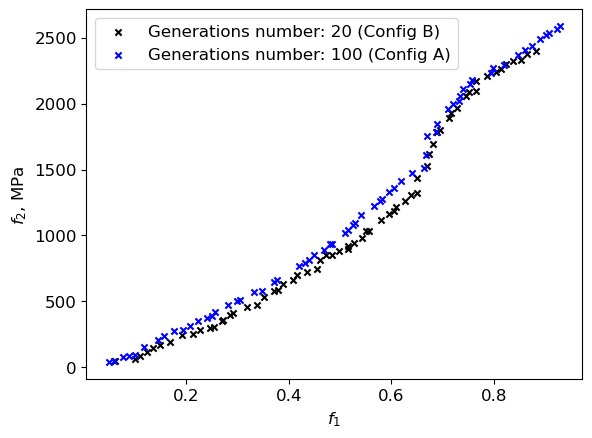

In [18]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=B_ds["volume_fraction"],
    y=B_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="Generations number: 20 (Config B)"
)

ax.scatter(
    x=A_ds["volume_fraction"],
    y=A_ds["young_module"],
    s=20,
    c="blue",
    marker="x",
    label="Generations number: 100 (Config A)"
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

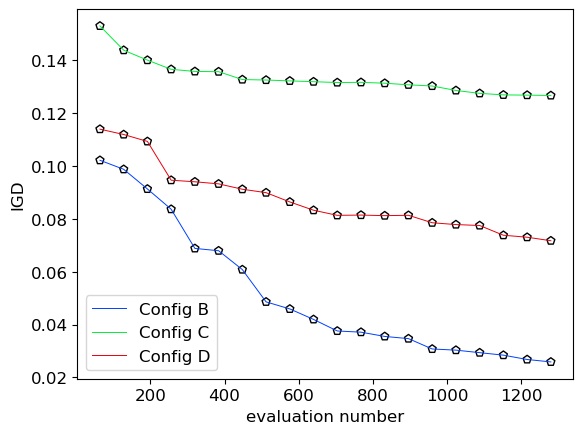

In [19]:
fig, ax = plt.subplots(dpi=dpi)

target_pf = A_ds[["volume_fraction", "young_module"]].to_numpy()
target_pf[:, 1] = -target_pf[:, 1]
metric = IGD(target_pf, zero_to_one=True)


n_evals = optimization_hist["n_evals"]
hist_F = optimization_hist["hist_F"]
hist_cv = optimization_hist["hist_cv"]
hist_cv_avg = optimization_hist["hist_cv_avg"]

igd = [metric.do(_F) for _F in hist_F]

ax.plot(n_evals, igd, lw=0.7, label="Config B")
ax.scatter(n_evals, igd,  facecolor="none", edgecolor='black', marker="p")


n_evals = C_hist["n_evals"]
hist_F = C_hist["hist_F"]
hist_cv = C_hist["hist_cv"]
hist_cv_avg = C_hist["hist_cv_avg"]

igd = [metric.do(_F) for _F in hist_F]

ax.plot(n_evals, igd, lw=0.7, label="Config C")
ax.scatter(n_evals, igd,  facecolor="none", edgecolor='black', marker="p")


n_evals = D_hist["n_evals"]
hist_F = D_hist["hist_F"]
hist_cv = D_hist["hist_cv"]
hist_cv_avg = D_hist["hist_cv_avg"]

igd = [metric.do(_F) for _F in hist_F]

ax.plot(n_evals, igd, lw=0.7, label="Config D")
ax.scatter(n_evals, igd,  facecolor="none", edgecolor='black', marker="p")


ax.set_xlabel("evaluation number")
ax.set_ylabel("IGD")
ax.legend()
plt.show()

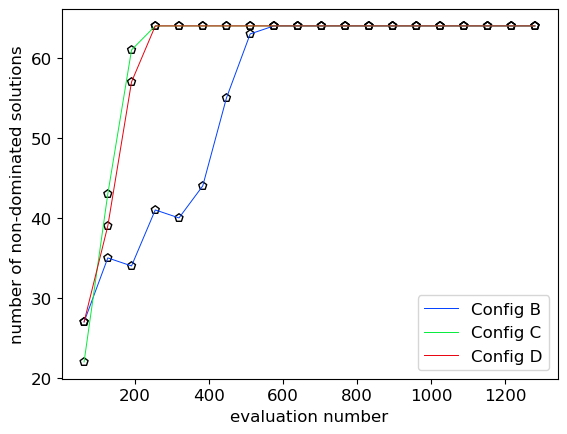

In [20]:
fig, ax = plt.subplots(dpi=dpi)

target_pf = A_ds[["volume_fraction", "young_module"]].to_numpy()
target_pf[:, 1] = -target_pf[:, 1]
metric = IGD(target_pf, zero_to_one=True)


n_evals = optimization_hist["n_evals"]
hist_F = optimization_hist["hist_F"]
hist_cv = optimization_hist["hist_cv"]
hist_cv_avg = optimization_hist["hist_cv_avg"]

n_nds = [F.shape[0] for F in hist_F]

ax.plot(n_evals, n_nds, lw=0.7, label="Config B")
ax.scatter(n_evals, n_nds,  facecolor="none", edgecolor='black', marker="p")


n_evals = C_hist["n_evals"]
hist_F = C_hist["hist_F"]
hist_cv = C_hist["hist_cv"]
hist_cv_avg = C_hist["hist_cv_avg"]

n_nds = [F.shape[0] for F in hist_F]

ax.plot(n_evals, n_nds, lw=0.7, label="Config C")
ax.scatter(n_evals, n_nds,  facecolor="none", edgecolor='black', marker="p")


n_evals = D_hist["n_evals"]
hist_F = D_hist["hist_F"]
hist_cv = D_hist["hist_cv"]
hist_cv_avg = D_hist["hist_cv_avg"]

n_nds = [F.shape[0] for F in hist_F]

ax.plot(n_evals, n_nds, lw=0.7, label="Config D")
ax.scatter(n_evals, n_nds,  facecolor="none", edgecolor='black', marker="p")


ax.set_xlabel("evaluation number")
ax.set_ylabel("number of non-dominated solutions")
ax.legend()
plt.show()

### Подсчет IGD+

In [21]:
print(f"Config B (IGD+): {metric(B_res[1])}")
print(f"Config C (IGD+): {metric(C_res[1])}")
print(f"Config D (IGD+): {metric(D_res[1])}")
print(f"Config F (IGD+): {metric(F_res[1])}")
print(f"Config G (IGD+): {metric(G_res[1])}")

Config B (IGD+): 0.025849804228042943
Config C (IGD+): 0.12669614054145584
Config D (IGD+): 0.07172301581751224
Config F (IGD+): 0.07947821301234621
Config G (IGD+): 0.06811149920705853


### Сравнение пространств Z и W

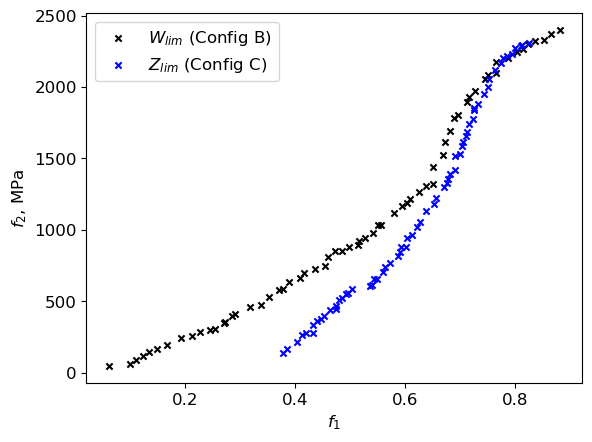

In [22]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=B_ds["volume_fraction"],
    y=B_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="$W_{lim}$ (Config B)"
)

ax.scatter(
    x=C_ds["volume_fraction"],
    y=C_ds["young_module"],
    s=20,
    c="blue",
    marker="x",
    label="$Z_{lim}$ (Config C)"
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

### Сравнение диапазонов lover bound и upper bound

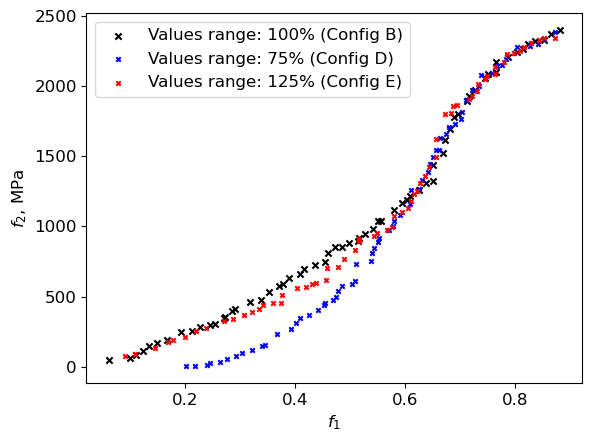

In [22]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=B_ds["volume_fraction"],
    y=B_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="Values range: 100% (Config B)"
)

ax.scatter(
    x=D_ds["volume_fraction"],
    y=D_ds["young_module"],
    s=10,
    c="blue",
    marker="x",
    label="Values range: 75% (Config D)"
)


ax.scatter(
    x=E_ds["volume_fraction"],
    y=E_ds["young_module"],
    s=10,
    c="red",
    marker="x",
    label="Values range: 125% (Config E)"
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

### Сравнение гиперпараметров NSGA-II

In [23]:
res_name = "024000_141_w_nc2_64"
with open(r"../optimization/results/" + res_name, "rb") as f:
    HZ_res = pickle.load(f)

HZ_ds = pd.DataFrame({"volume_fraction": HZ_res[1][:, 0], "young_module": -HZ_res[1][:, 1]})
HZ_ds["class"] = res_name

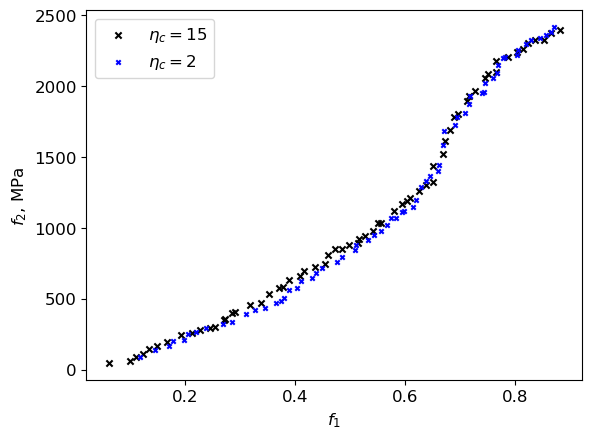

In [24]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=B_ds["volume_fraction"],
    y=B_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="$\eta_c=15$"
)

ax.scatter(
    x=HZ_ds["volume_fraction"],
    y=HZ_ds["young_module"],
    s=10,
    c="blue",
    marker="x",
    label="$\eta_c=2$"
)

ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

### Сравнение архитектур по FID

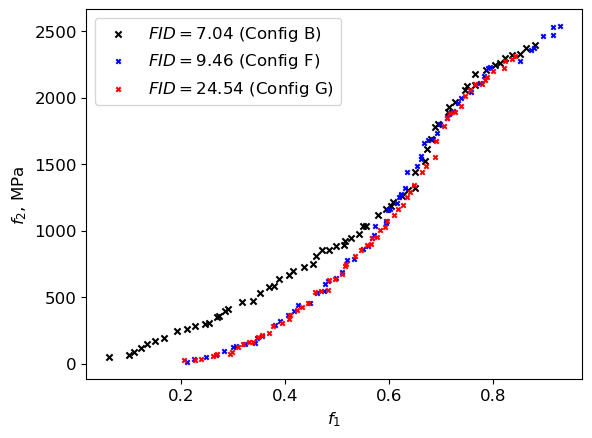

In [25]:
fig, ax = plt.subplots(dpi=dpi)

ax.scatter(
    x=B_ds["volume_fraction"],
    y=B_ds["young_module"],
    s=20,
    c="black",
    marker="x",
    label="$FID=7.04$ (Config B)"
)


ax.scatter(
    x=G_ds["volume_fraction"],
    y=G_ds["young_module"],
    s=10,
    c="blue",
    marker="x",
    label="$FID=9.46$ (Config F)"
)


ax.scatter(
    x=F_ds["volume_fraction"],
    y=F_ds["young_module"],
    s=10,
    c="red",
    marker="x",
    label="$FID=24.54$ (Config G)"
)


ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters
ax.legend()

# UMAP

In [26]:
import umap
import tensorflow as tf
from umap.parametric_umap import ParametricUMAP

In [76]:
x_opt = copy.deepcopy(A_res[0])

In [56]:
x_opt.shape

(64, 128)

In [29]:
tf.random.set_seed(1)
np.random.seed(1)

embedder = ParametricUMAP(
    n_neighbors=15,
    min_dist=0.0,
    n_components=2,
    metric='euclidean', # можно 'manhattan'
    random_state=1,
    verbose=True
)
embedder.fit(x_opt)

C:\Users\Evgeniy\Anaconda3\envs\tf-torch\lib\site-packages\umap\parametric_umap.py:148: UserWarning: tensorflow_probability not installed or incompatible to current                 tensorflow installation. Setting global_correlation_loss_weight to zero.
  warn(


ParametricUMAP(optimizer=<keras.optimizers.optimizer_v2.adam.Adam object at 0x000002BF438D24F0>)
Thu Jul 13 13:01:59 2023 Construct fuzzy simplicial set
Thu Jul 13 13:01:59 2023 Finding Nearest Neighbors
Thu Jul 13 13:02:00 2023 Finished Nearest Neighbor Search
Thu Jul 13 13:02:02 2023 Construct embedding
Epoch 1/10
310/310 [==============================] - 1s 1ms/step - loss: 0.5888
Epoch 2/10
310/310 [==============================] - 0s 1ms/step - loss: 0.4371
Epoch 3/10
310/310 [==============================] - 0s 1ms/step - loss: 0.4219
Epoch 4/10
310/310 [==============================] - 0s 1ms/step - loss: 0.4231
Epoch 5/10
310/310 [==============================] - 0s 1ms/step - loss: 0.4260
Epoch 6/10
310/310 [==============================] - 0s 1ms/step - loss: 0.4267
Epoch 7/10
310/310 [==============================] - 0s 1ms/step - loss: 0.4274
Epoch 8/10
310/310 [==============================] - 0s 1ms/step - loss: 0.4254
Epoch 9/10
310/310 [=========================

ParametricUMAP(batch_size=64, dims=[128], encoder=<keras.engine.sequential.Sequential object at 0x000002BF501A7E50>, optimizer=<keras.optimizers.optimizer_v2.adam.Adam object at 0x000002BF438D24F0>)

In [30]:
umap_embedding = embedder.transform(x_opt)

1/1 [==============================] - 0s 34ms/step


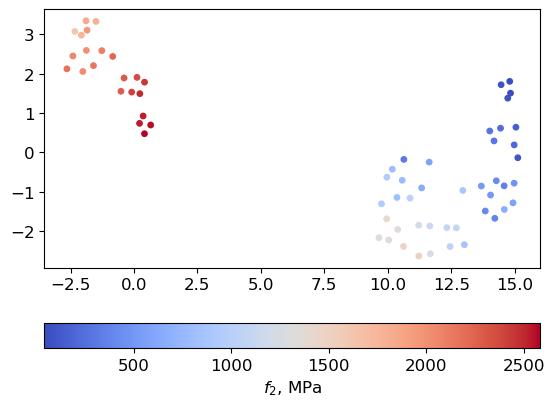

In [34]:
# Интересно взять точку с кластера, построить микроструктуру и сравнить их с другими кластерами
# Выдвигаю гипотезу, что 
fig, ax = plt.subplots(dpi=dpi)

img = ax.scatter(
    umap_embedding[:, 0],
    umap_embedding[:, 1],
    c=A_ds["young_module"],
    cmap="coolwarm",
    s=15
)

fig.colorbar(img, ax=ax, label="$f_2$, MPa", orientation="horizontal")

In [35]:
np.argsort(-A_res[1][:, 1])[44]

24

Text(0, 0.5, '$f_2$, MPa')

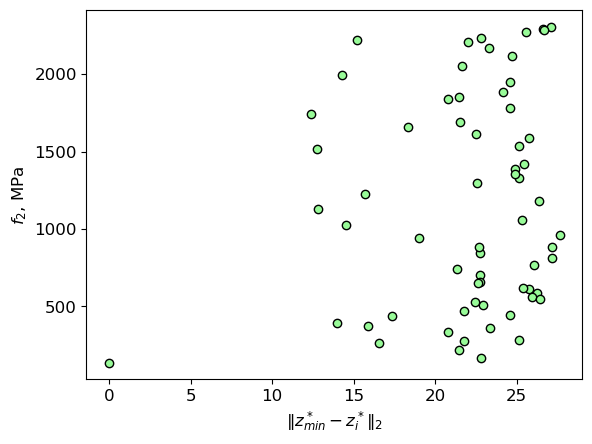

In [72]:
"""
Нужно построить график зависимости нормы (или cosine sim) кодировок в W между самой "прочной"
микроструктурой и всех остальных, а также между самой "слабой" и всех остальных

Сделать то же самое для пространства Z и сравнить графики

Где будет более линейный график, там "структура" пространства лучше (но вообще не факт)
"""

max_ym_idx = np.argmax(C_res[1], axis=0)[1]
#x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
y = -C_res[1][:, 1]

fig, ax = plt.subplots(dpi=dpi)
ax.scatter(x, y, edgecolor="black", c="palegreen")
ax.set_xlabel("$\Vert {z}^*_{min} - z^*_{i}\Vert_2$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters

Text(0, 0.5, '$f_2$, MPa')

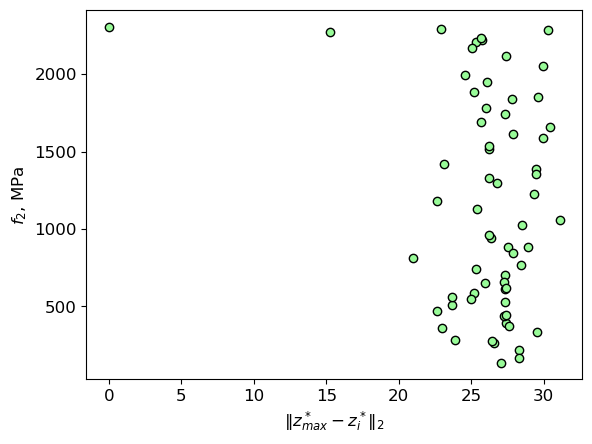

In [73]:
"""
Нужно построить график зависимости нормы (или cosine sim) кодировок в W между самой "прочной"
микроструктурой и всех остальных, а также между самой "слабой" и всех остальных

Сделать то же самое для пространства Z и сравнить графики

Где будет более линейный график, там "структура" пространства лучше (но вообще не факт)
"""

max_ym_idx = np.argmin(C_res[1], axis=0)[1]
#x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
y = -C_res[1][:, 1]

fig, ax = plt.subplots(dpi=dpi)
ax.scatter(x, y, edgecolor="black", c="palegreen")
ax.set_xlabel("$\Vert {z}^*_{max} - z^*_{i}\Vert_2$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters

Text(0, 0.5, '$f_2$, MPa')

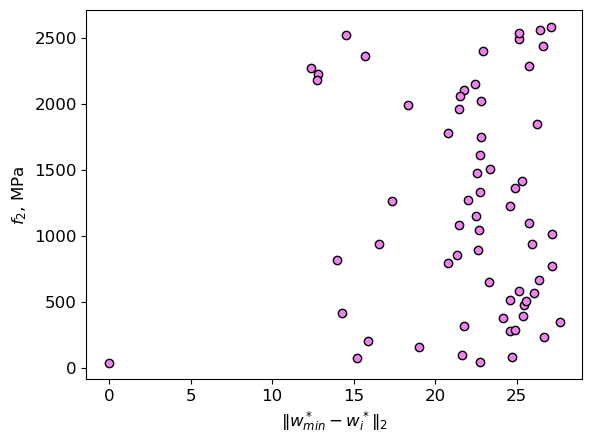

In [74]:
"""
Нужно построить график зависимости нормы (или cosine sim) кодировок в W между самой "прочной"
микроструктурой и всех остальных, а также между самой "слабой" и всех остальных

Сделать то же самое для пространства Z и сравнить графики

Где будет более линейный график, там "структура" пространства лучше (но вообще не факт)
"""

max_ym_idx = np.argmax(A_res[1], axis=0)[1]
#x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
y = -A_res[1][:, 1]

fig, ax = plt.subplots(dpi=dpi)
ax.scatter(x, y, edgecolor="black", c="violet")
ax.set_xlabel("$\Vert {w}^*_{min} - w^*_{i}\Vert_2$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters

Text(0, 0.5, '$f_2$, MPa')

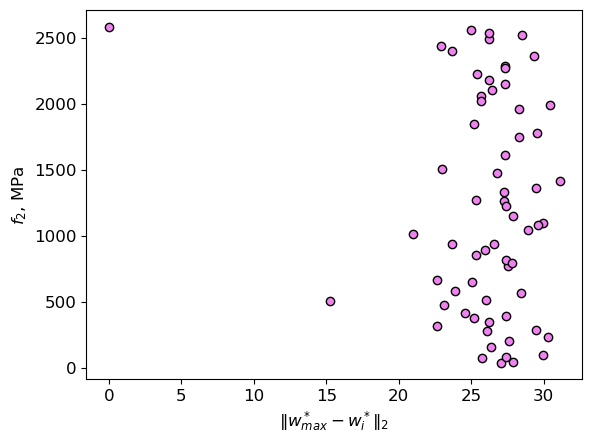

In [75]:
"""
Нужно построить график зависимости нормы (или cosine sim) кодировок в W между самой "прочной"
микроструктурой и всех остальных, а также между самой "слабой" и всех остальных

Сделать то же самое для пространства Z и сравнить графики

Где будет более линейный график, там "структура" пространства лучше (но вообще не факт)
"""

max_ym_idx = np.argmin(A_res[1], axis=0)[1]
#x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
x = [np.linalg.norm(x_opt[max_ym_idx] - sample) for sample in x_opt]
y = -A_res[1][:, 1]

fig, ax = plt.subplots(dpi=dpi)
ax.scatter(x, y, edgecolor="black", c="violet")
ax.set_xlabel("$\Vert {w}^*_{max} - w^*_{i}\Vert_2$")
ax.set_ylabel("$f_2$, MPa") # MPa because the model size in millimeters

In [47]:
# Взять кластер, где находятся самые "прочные" микроструктуры
# И сравнить его кодировку в W с x_opt[idx], где idx - индекс самой "прочной" микроструктуры
idx = 36
idxs = umap_embedding[:, 1] > 0
samples = x_opt[idxs]
for sample in samples:
    print(np.linalg.norm(x_opt[idx] - sample))

1.0203915362967129
0.9244530779947945
1.1054987588206129
1.0534269677285213
0.9750515871469939
0.8791856809285128
1.0912856437360938
0.9161883914422787
0.9862358769068942
1.0873840439827378
0.7491503540452719
0.8965881891777604
1.1054016627190761
1.0438637978053074
0.8891023178009339
1.036147924647333
0.947601498476825
1.0172918517290594
1.0254949388017642
0.7906932095159419
1.0211307883045726
1.0263236405850584
0.7065169899321051
0.9787533742514937
0.6846470679196436
0.6654219281613338
0.9964976928705203
0.8847808454056011
0.720927714652056
0.99616785895424
0.8826454828426528


# Microstructure visualizaton

In [48]:
import torch 
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from torch import nn
from training_loop import data_plot, generate_noise, mixing_regularization
from network import MappingNetwork, Generator, StyleBlock

In [112]:
def generate(net_M, net_G, var, var_shapes, opt_space, block_zero_noise=None):
    n_blocks = net_G.n_blocks
    var = np.expand_dims(var, 0)
    device = next(net_G.parameters()).device

    with torch.no_grad():
        if opt_space == "w+noise":
            zero_noise = generate_noise(1, n_blocks, blocks_zero_noise=[i for i in range(n_blocks)])
            zero_noise = [zero_noise[i].to(device) for i in blocks_zero_noise]
            var = torch.from_numpy(var).to(device=device, dtype=torch.float32)
            w_noise = decompose_var(var, var_shapes)
            w, noise = w_noise[0], w_noise[1:] + zero_noise
            w = mixing_regularization([w], n_blocks)
        if opt_space == "w":
            noise = generate_noise(1, n_blocks, device=device, blocks_zero_noise=[i for i in range(n_blocks)])
            w = [torch.from_numpy(var).to(device=device, dtype=torch.float32)]
            w = mixing_regularization(w, n_blocks)
        if opt_space == "z":
            noise = generate_noise(1, n_blocks, device=device, blocks_zero_noise=[i for i in range(n_blocks)])
            z = [torch.from_numpy(var).to(device=device, dtype=torch.float32)]
            w = [net_M(z_i) for z_i in z]
            w = mixing_regularization(w, n_blocks)

        x = net_G(w, noise)
        x = torch.where(x >= 0, 1., -1.) * 0.5 + 0.5
        x = x.cpu().numpy()
        data_plot(x[0, 0])
        plt.show()
        return x

In [50]:
batch_size = 64
d_latent = 128
n_layers = 4
lr_multiplier = 0.01
log_resolution = 6
n_features = 32
max_features = 128
activation = nn.Tanh()

net_M = MappingNetwork(d_latent, n_layers, lr_multiplier).eval()
net_G = Generator(log_resolution, d_latent, n_features, max_features, activation=activation).eval()

ckpt = "024000_141"
ckpt_path = r"../checkpoint/" + ckpt + ".pt"

checkpoint = torch.load(ckpt_path, map_location=torch.device("cpu"))
net_M.load_state_dict(checkpoint["net_M_ema"])
net_G.load_state_dict(checkpoint["net_G_ema"])

C:\Users\Evgeniy\Jupyter\Work\materials-design\network.py:161: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at  C:\cb\pytorch_1000000000000\work\torch\csrc\utils\tensor_new.cpp:204.)
  kernel = torch.tensor([[kernel]], dtype=torch.float)


<All keys matched successfully>

In [132]:
fig = go.Figure()

temp = train_ds_info[train_ds_info["volume_fraction_error"] < 5].sample(1000, random_state=2)
x = temp["volume_fraction"]
y = temp["young_module"]
fig.add_trace(
    go.Scatter(
        x=x,
        y=y,
        mode="markers",
        marker_symbol="triangle-up",
        marker_color="black"
    )
)

fig.add_trace(
    go.Scatter(
        x=A_ds["volume_fraction"],
        y=A_ds["young_module"],
        mode="markers",
        marker_symbol="x",
    )
)
fig.show()

In [77]:
A_ds["young_module"].to_numpy()

array([  39.30196376, 2585.95065563, 1847.20913382, 1957.40251352,
       2290.34878941, 2365.38770492, 1752.01089142, 1474.383218  ,
       1413.11140265,  472.92295151, 2228.31878189, 2177.0497249 ,
       1015.64430472,  569.47054008, 1610.86382457,  418.19501012,
        939.07756086,  514.1604215 ,  154.2114242 , 2490.99366755,
       1331.11011107,   95.98989071,  349.32432629, 1362.85406577,
       1782.19853353, 1508.05825954, 2108.33208976, 2402.28446766,
       1153.19238819,  582.26148323, 1993.70891155,  770.85546809,
        374.05018295,   77.24348054, 1274.80747821, 2150.42859976,
       1093.89718594,   46.99686056, 2439.50939403,  315.62651913,
       2060.48312715,  814.21025873, 2020.18752691,  505.1191695 ,
       1043.04175085,  205.38422184,  891.93020099, 2534.65384827,
        275.0015244 ,  794.04610813,  854.79834417,  282.91272957,
        937.00976149, 2523.11860182, 2561.86991955,  235.65517954,
       1263.77072028, 1080.99309106,  392.85335952, 2269.77644

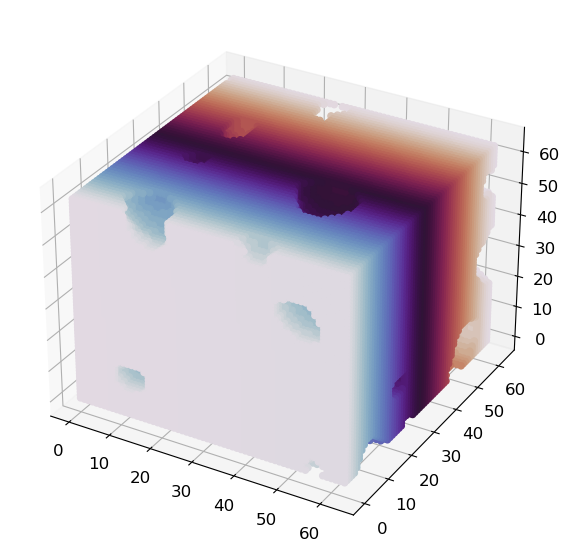

In [113]:
select_idx = A_ds["young_module"] == 2585.95065563
w = x_opt[select_idx]
struct = generate(net_M, net_G, w[0], None, "w")
np.save("ym_2585.npy", struct)

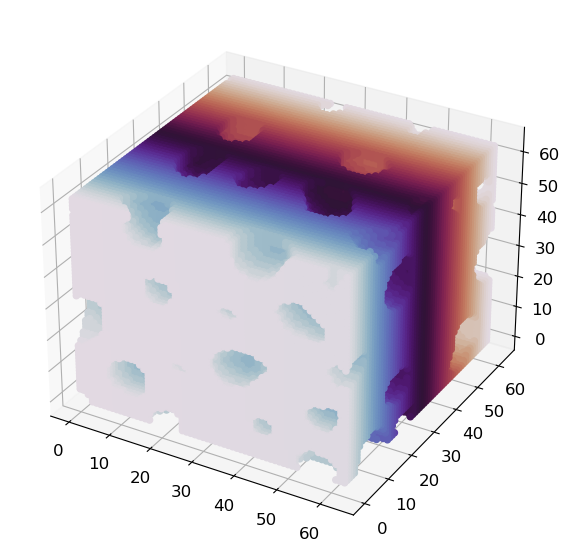

In [115]:
select_idx = A_ds["young_module"] == 2290.34878941
w = x_opt[select_idx]
struct = generate(net_M, net_G, w[0], None, "w")
np.save("ym_2290.npy", struct)

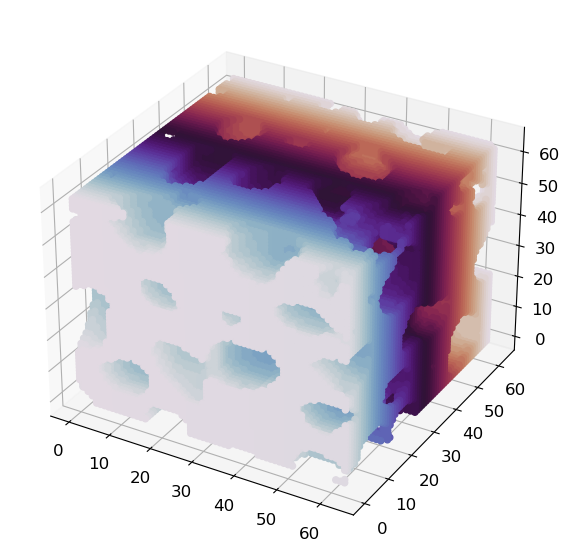

In [116]:
select_idx = A_ds["young_module"] == 1752.01089142
w = x_opt[select_idx]
struct = generate(net_M, net_G, w[0], None, "w")
np.save("ym_1752.npy", struct)

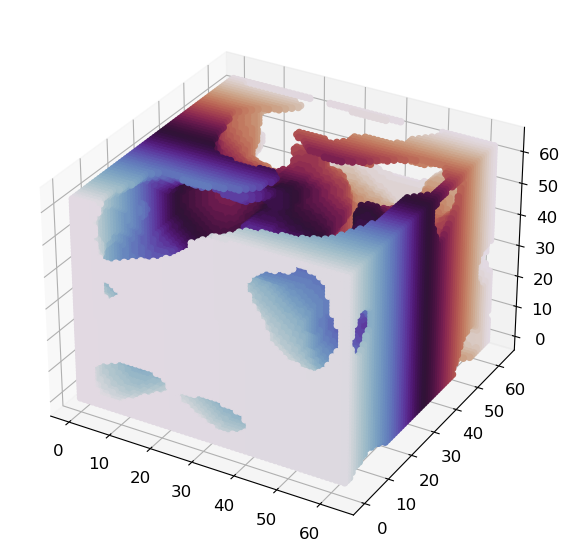

In [117]:
select_idx = A_ds["young_module"] == 1474.383218
w = x_opt[select_idx]
struct = generate(net_M, net_G, w[0], None, "w")
np.save("ym_1474.npy", struct)

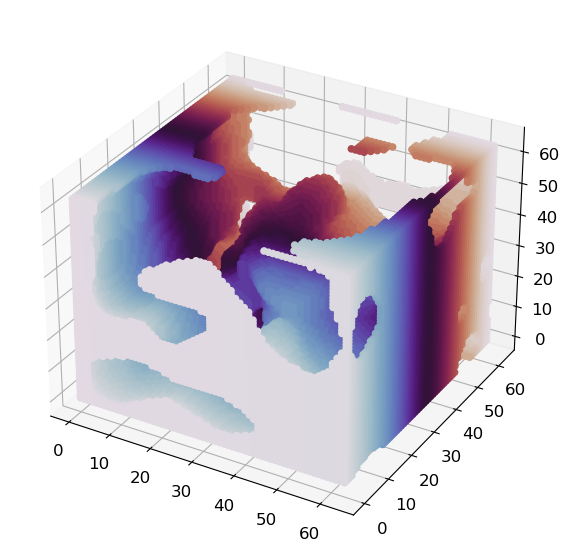

In [118]:
select_idx = (A_ds["young_module"] > 794) & (A_ds["young_module"] < 795)
w = x_opt[select_idx]
struct = generate(net_M, net_G, w[0], None, "w")
np.save("ym_794.npy", struct)

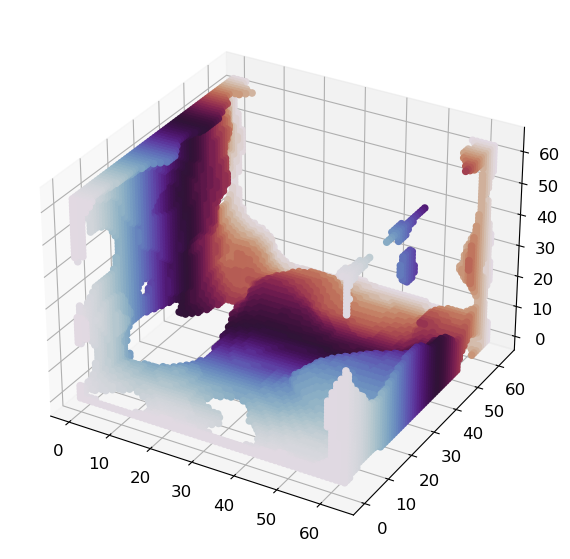

In [119]:
select_idx = (A_ds["young_module"] > 154) & (A_ds["young_module"] < 155)
w = x_opt[select_idx]
struct = generate(net_M, net_G, w[0], None, "w")
np.save("ym_154.npy", struct)

In [120]:
# Интересно взять точку с кластера, построить микроструктуру и сравнить их с другими кластерами
# Выдвигаю гипотезу, что 
fig = px.scatter(
    x=umap_embedding[:, 0],
    y=umap_embedding[:, 1],
    color=A_ds["young_module"]
)
fig.show()
#fig.colorbar(img, ax=ax, label="$f_2$, MPa", orientation="horizontal")

In [76]:
umap_embedding[:, 0]

array([-0.85728246,  3.3908765 ,  0.80029136, -1.6604881 ,  6.1475396 ,
        1.2102867 , -0.14620487, -0.26785493,  0.6733651 ,  4.145643  ,
        0.80712354, -1.5533078 ,  1.0323243 ,  2.841183  ,  0.6166608 ,
        3.1017194 ,  1.431317  , -0.3750979 ,  2.777858  ,  0.5099907 ,
       -2.2830083 , -0.97134584,  3.9927127 ,  1.1270673 ,  3.851955  ,
        2.8891306 , -2.347392  ,  2.7078884 ,  4.8802524 ,  4.036566  ,
        4.752139  , -1.4328389 , -1.7660148 , -0.6601607 ,  4.181556  ,
        0.9434901 ,  1.3045188 ,  2.322129  , -2.5565188 ,  5.9853134 ,
        5.4104376 ,  4.447075  ,  4.0976496 , -2.6919825 , -1.9954717 ,
        2.9569082 ,  3.8519218 ,  4.1425014 , -0.5403432 , -1.116362  ,
        3.7632577 ,  2.1289594 ,  6.0685205 ,  3.8753088 ,  0.8565849 ,
        0.9629145 ,  0.7497961 ,  5.7188683 ,  4.8807707 ,  0.5689046 ,
       -2.5016658 ,  4.3973327 ,  1.5780311 ,  3.2786717 ,  2.8269289 ,
        6.18583   ,  1.1728332 ,  6.2191634 ,  0.6359435 ,  2.64

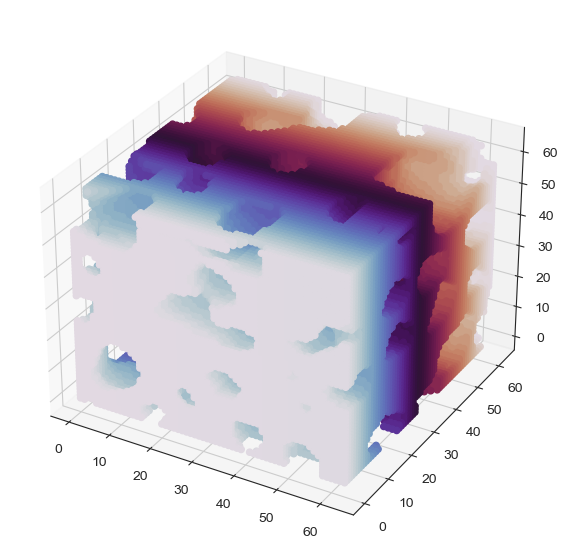

In [89]:
select_idx = umap_embedding[:, 0] == -0.97134584
w = x_opt[select_idx]

generate(net_M, net_G, w[0], None, "w")

# Pymoo test

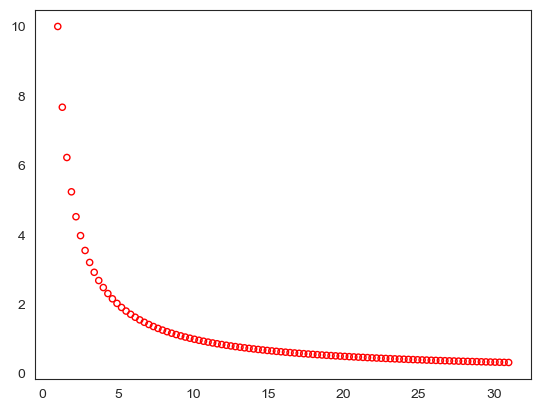

In [23]:
from pymoo.problems import get_problem
from pymoo.util.plotting import plot

problem = get_problem("zdt5", normalize=False)
plot(problem.pareto_front(), no_fill=True)

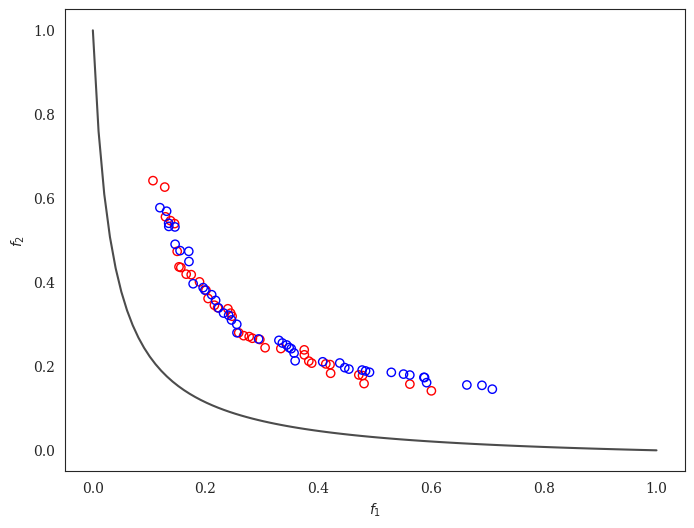

In [24]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.sampling.lhs import LHS
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PolynomialMutation as PM

problem = get_problem("zdt5")

algorithm = NSGA2(
    pop_size=100,
    sampling=LHS(iterations=1000),
    crossover=SBX(eta=5, prob=0.9),
    mutation=PM(eta=2)
)

res = minimize(problem,
               algorithm,
               ('n_gen', 10),
               seed=1,
               verbose=False)

algorithm = NSGA2(
    pop_size=100,
    sampling=LHS(iterations=1000),
    crossover=SBX(eta=5, prob=0.9),
    mutation=PM(eta=20)
)

res2 = minimize(problem,
               algorithm,
               ('n_gen', 10),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.add(res2.F, facecolor="none", edgecolor="blue")
plot.show()

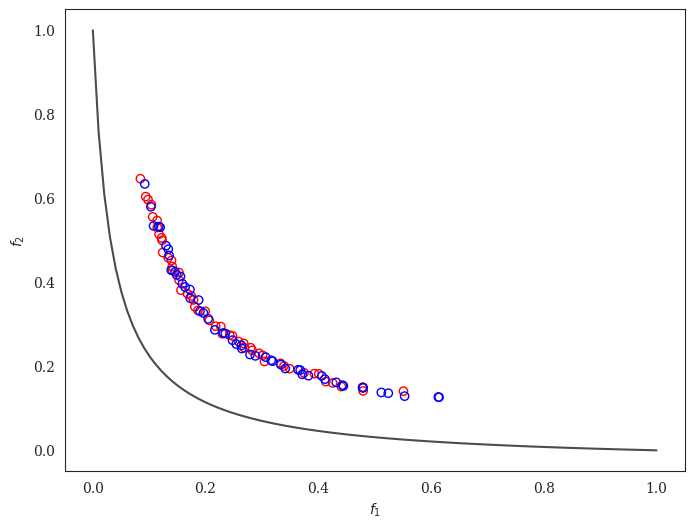

In [42]:
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.problems import get_problem
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter
from pymoo.operators.sampling.lhs import LHS
from pymoo.operators.crossover.sbx import SBX
from pymoo.operators.mutation.pm import PolynomialMutation as PM

problem = get_problem("zdt5")

algorithm = NSGA2(
    pop_size=50,
    sampling=LHS(iterations=1000),
    crossover=SBX(eta=5, prob=0.9),
    mutation=PM(eta=2)
)

res = minimize(problem,
               algorithm,
               ('n_gen', 20),
               seed=1,
               verbose=False)

algorithm = NSGA2(
    pop_size=50,
    sampling=LHS(iterations=1000),
    crossover=SBX(eta=5, prob=0.9),
    mutation=PM(eta=20)
)

res2 = minimize(problem,
               algorithm,
               ('n_gen', 20),
               seed=1,
               verbose=False)

plot = Scatter()
plot.add(problem.pareto_front(), plot_type="line", color="black", alpha=0.7)
plot.add(res.F, facecolor="none", edgecolor="red")
plot.add(res2.F, facecolor="none", edgecolor="blue")
plot.show()